link al repositorio: https://github.com/paulabaal12/LAB8-RL.git

# Task 1  — Task 1.1

In [ ]:
import numpy as np, time
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (7, 3.6), "axes.grid": True, "grid.alpha": .3})
rng = np.random.default_rng(0)

def beta_star(v):
    return np.maximum(0.0, 2.5 * (v - 12.0))      # grados

def reward(beta, v, width=8.0):
    return np.exp(-((beta - beta_star(v)) / width) ** 2)

BETA_MIN, BETA_MAX = 0.0, 30.0

---
# 1.1 (a)

DQN aproxima $Q_\theta(s,a)$ y depende del operador $\max$/$\arg\max$ en **dos** lugares:

1. **Selección de acción (política):** $\;\pi(s) = \arg\max_{a\in\mathcal{A}} Q_\theta(s,a)$
2. **Objetivo de Bellman (entrenamiento):** $\;y = r + \gamma \max_{a'\in\mathcal{A}} Q_{\theta^-}(s',a')$

(Double DQN cambia *quién* elige $a'$ pero sigue necesitando un $\arg\max$; Dueling cambia la arquitectura de la red; Prioritized Replay cambia el muestreo. Ninguna de estas variantes elimina el $\arg\max$.)

En un espacio **discreto y pequeño**, ese $\arg\max$ es trivial: la red produce un vector de $|\mathcal{A}|$ salidas y se toma el máximo en $O(|\mathcal{A}|)$. Con $\mathcal{A} = [a_{\min},a_{\max}]^d$ **continuo**:

- $\arg\max_a Q_\theta(s,a)$ es un **problema de optimización continuo en cada paso**, sobre una función $Q_\theta$ parametrizada por una red neuronal, que en general es **no convexa** en $a$. No tiene solución cerrada, y los métodos iterativos (ascenso por gradiente, CEM, muestreo) solo garantizan óptimos locales.
- Esa optimización debe resolverse **(i)** en cada paso de control en tiempo real y **(ii)** para **cada muestra del minibatch** al calcular el objetivo $y$. El costo de entrenamiento se multiplica por (tamaño de batch) × (iteraciones del optimizador interno).

### Consecuencias computacionales de aplicar DQN "directamente"

#### Opción 1 .

$$|\mathcal{A}_{\text{disc}}| = K^{d} \qquad \text{(maldición de la dimensionalidad)}$$

Además hay dos costos que no aparecen en la cuenta anterior:
- **Error de discretización (resolución):** el controlador nunca puede elegir un ángulo entre dos nodos de la malla, así que existe una pérdida irreducible de potencia $\propto \Delta^2$ con $\Delta = (a_{\max}-a_{\min})/K$ (para $r$ suave con máximo interior). Reducir $\Delta$ incrementa $K$ y por tanto el costo.
- **Se pierde la estructura:** DQN trata las $K^d$ acciones como categorías independientes, aunque $Q(s,a)$ y $Q(s,a+\epsilon)$ son casi iguales físicamente. Esto empeora la eficiencia de datos: cada acción de la malla necesita sus propios datos.
- **Control brusco (*chattering*):** con malla gruesa el controlador salta entre nodos, lo que acelera el desgaste mecánico del actuador de pitch.

#### Opción 2 

### La solución estructural (lo que motiva la siguiente pregunta)

Los métodos **actor-crítico** reemplazan el $\arg\max$ por una **política paramétrica** $\mu_\phi(s)$ entrenada para maximizar $Q$ mediante el gradiente de política determinista (Silver et al., 2014):

$$\nabla_\phi J \approx \mathbb{E}_{s}\Big[\nabla_a Q_\theta(s,a)\big|_{a=\mu_\phi(s)}\;\nabla_\phi\mu_\phi(s)\Big]$$

Así el "$\arg\max$" se amortiza en una sola pasada hacia adelante de la red actor: costo $O(1)$ por paso, independiente de $d$ y de la resolución.

In [2]:
# --- Demostración 1: explosión del número de acciones K^d ---
Ks, ds = [10, 50, 100], [1, 2, 3, 5]
print(f"{'K \\ d':>6}" + "".join(f"{d:>16}" for d in ds))
for K in Ks:
    print(f"{K:>6}" + "".join(f"{K**d:>16,}" for d in ds))
print("\nCon d=5 (3 palas individuales + yaw + torque) y K=50: ", f"{50**5:,}", "salidas en la última capa de la red.")

 K \ d               1               2               3               5
    10              10             100           1,000         100,000
    50              50           2,500         125,000     312,500,000
   100             100          10,000       1,000,000  10,000,000,000

Con d=5 (3 palas individuales + yaw + torque) y K=50:  312,500,000 salidas en la última capa de la red.


In [ ]:
# --- Demostración 2: costo de un argmax por fuerza bruta en una malla (un solo estado) ---
def Q_toy(A):                       # A: (n_actions, d)
    return np.exp(-((A - 0.3) ** 2).sum(axis=1) * 5.0)

K = 30
print(f"{'d':>3} {'#acciones':>12} {'tiempo argmax (ms)':>20}")
t_prev = None
for d in [1, 2, 3, 4]:
    grid = np.stack(np.meshgrid(*[np.linspace(0, 1, K)] * d, indexing="ij"), -1).reshape(-1, d)
    t0 = time.perf_counter(); _ = grid[np.argmax(Q_toy(grid))]; t = (time.perf_counter() - t0) * 1e3
    print(f"{d:>3} {len(grid):>12,} {t:>20.2f}")
    t_prev = t
print(f"\nExtrapolación a d=5: ~{K**5:,} acciones => ~{t_prev*K:,.0f} ms POR ESTADO (y por cada muestra del batch en el target).")

  d    #acciones   tiempo argmax (ms)
  1           30                 0.46
  2          900                 0.09
  3       27,000                 0.94
  4      810,000                40.95

Extrapolación a d=5: ~24,300,000 acciones => ~1,229 ms POR ESTADO (y por cada muestra del batch en el target).


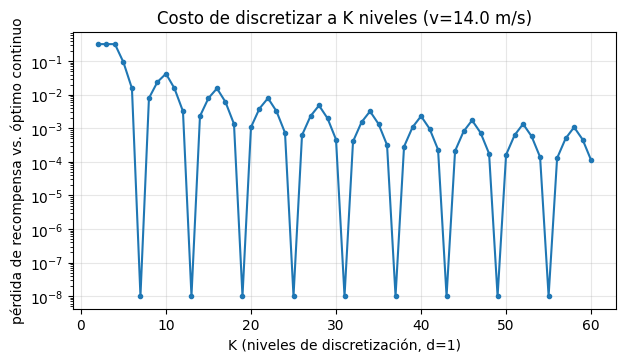

Con K=5 se pierde 9.3% de la recompensa; hacen falta K grande => K^d salidas en d>1.


In [4]:
# --- Demostración 3: pérdida por discretización (d=1) ---
v = 14.0                                   # viento de prueba -> beta*(14)=5 grados
Ks = np.arange(2, 61)
best = []
for K in Ks:
    grid = np.linspace(BETA_MIN, BETA_MAX, K)
    best.append(reward(grid, v).max())
regret = 1.0 - np.array(best)              # el máximo continuo es 1.0

fig, ax = plt.subplots()
ax.semilogy(Ks, np.maximum(regret, 1e-8), "o-", ms=3)
ax.set_xlabel("K (niveles de discretización, d=1)"); ax.set_ylabel("pérdida de recompensa vs. óptimo continuo")
ax.set_title(f"Costo de discretizar a K niveles (v={v} m/s)")
plt.show()
print("Con K=5 se pierde", f"{regret[3]*100:.1f}%", "de la recompensa; hacen falta K grande => K^d salidas en d>1.")

---
# 1.1 (b) TD3 vs. SAC para el sistema de control en producción

Ambos son actor-crítico **off-policy** con críticos dobles (clipped double-Q) para frenar la sobreestimación, y ambos resuelven el problema del $\arg\max$ continuo. Se diferencian en la política y en cómo exploran:

| | **TD3** (Fujimoto et al., 2018) | **SAC** (Haarnoja et al., 2018) |
|---|---|---|
| Política | Determinista $\mu_\phi(s)$ | Estocástica $\pi_\phi(a\mid s)$ (gaussiana + tanh) |
| Objetivo | $\mathbb{E}\sum\gamma^t r_t$ | $\mathbb{E}\sum\gamma^t\,[\,r_t + \alpha\,\mathcal{H}(\pi(\cdot\mid s_t))\,]$ (máxima entropía) |
| Exploración | Ruido externo agregado a la acción (hiperparámetro $\sigma$) | Intrínseca, vía entropía; $\alpha$ puede ajustarse automáticamente |
| Regularización | *Target policy smoothing* + actualización retrasada del actor | Entropía como regularizador |

## Argumentos a favor de TD3

1. **Naturaleza física del sistema.** En un sistema de control industrial se valora una ley de control **determinista, reproducible y auditable**: mismo estado → misma acción. Una política estocástica desplegada implica *jitter* en el actuador de pitch (desgaste, fatiga mecánica) y complica certificación y análisis de fallos.
2. **Costo de la estocasticidad.** Si $r$ es localmente cóncava alrededor del óptimo, ejecutar $a\sim\mathcal{N}(\mu,\sigma^2)$ cuesta en promedio $\approx \tfrac12|r''|\sigma^2$ de recompensa (se verifica numéricamente abajo).
3. **Menos "piezas móviles" conceptuales:** el objetivo de TD3 es el retorno puro; no hay que decidir cuánta entropía vale en unidades de MW.

## Argumentos a favor de SAC

1. **Eficiencia de datos y estabilidad de entrenamiento.** SAC suele ser competitivo o superior a TD3 en muestras y mucho **menos sensible a hiperparámetros**: la exploración se auto-regula con $\alpha$ automático, mientras que TD3 exige afinar a mano el ruido de exploración. En simulación de dinámica de fluidos/aeroelástica, cada episodio es caro, así que esto importa.
2. **Robustez ante perturbaciones no vistas.** La máxima entropía mantiene a la política "ancha" mientras el crítico lo permita, de modo que aprende **varias** maneras razonables de actuar y no colapsa tempranamente a un máximo local estrecho del paisaje de $Q$. Eso suele traducirse en mejor comportamiento ante rachas de viento fuera de la distribución de entrenamiento. (TD3 obtiene una forma de suavidad con *target policy smoothing*, pero suaviza $Q$ respecto a la *acción*, no respecto a perturbaciones de *estado/dinámica* como el viento.)
3. **Despliegue determinista posible.** La estocasticidad de SAC es una herramienta de **entrenamiento**; en producción se puede desplegar la media $a=\tanh(\mu_\phi(s))$ y eliminar el jitter, que es justo la objeción de TD3.

## Posición

**Recomendamos SAC entrenado en simulación y desplegado en modo determinista (acción = media de la política)**, con TD3 como línea base obligatoria.

Razones: la objeción física a la política estocástica *desaparece* al desplegar la media; mientras que las ventajas de SAC (menor sensibilidad a hiperparámetros, exploración automática y política menos propensa a colapsar) se aprovechan durante el entrenamiento, que es donde son decisivas.


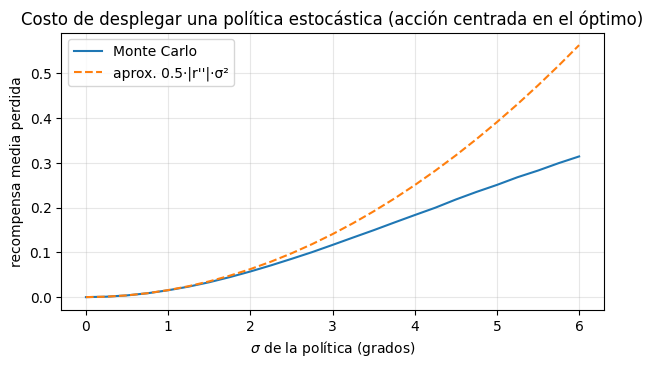

Con sigma=3 deg se pierde ~11.7% de recompensa, además de movimiento constante del actuador.
=> en producción se despliega la MEDIA de SAC (sigma=0): se conserva la calidad de entrenamiento sin el costo.


In [5]:
# --- Demostración 4: costo de desplegar una política estocástica (jitter) vs. determinista ---
v = 15.0; bstar = beta_star(v)
sigmas = np.linspace(0, 6, 25)                       # desviación estándar de la acción, en grados
N = 200_000
loss_mc = [1 - reward(bstar + s * rng.standard_normal(N), v).mean() for s in sigmas]
loss_approx = sigmas**2 / 8.0**2                      # 0.5*|r''|*sigma^2 con r''=-2/w^2

fig, ax = plt.subplots()
ax.plot(sigmas, loss_mc, label="Monte Carlo")
ax.plot(sigmas, loss_approx, "--", label="aprox. 0.5·|r''|·σ²")
ax.set_xlabel(r"$\sigma$ de la política (grados)"); ax.set_ylabel("recompensa media perdida")
ax.legend(); ax.set_title("Costo de desplegar una política estocástica (acción centrada en el óptimo)")
plt.show()
print(f"Con sigma=3 deg se pierde ~{loss_mc[12]*100:.1f}% de recompensa, además de movimiento constante del actuador.")
print("=> en producción se despliega la MEDIA de SAC (sigma=0): se conserva la calidad de entrenamiento sin el costo.")

---
# 1.1 (c)

**CQL** (Kumar et al., 2020) aprende un crítico **conservador** que lo lleva a *subestimar* el valor de acciones fuera del soporte de los datos, añadiendo al error de Bellman la penalización
$$\alpha\Big(\mathbb{E}_{s\sim\mathcal{D}}\big[\log\textstyle\sum_{a}\exp Q(s,a)\big]-\mathbb{E}_{(s,a)\sim\mathcal{D}}\big[Q(s,a)\big]\Big)$$
que baja $Q$ en acciones "no respaldadas" por el dataset y sube $Q$ en las que sí aparecen.

## Qué política de comportamiento $\beta$ generó los datos

Los datos son una **mezcla de políticas de operadores humanos** con distintos niveles de experiencia: $\beta(a\mid s)=\sum_k w_k\,\beta_k(a\mid s)$. Es de esperar que:

- **No sea óptima ni cercana a la óptima en promedio.** Los novatos introducen sesgos y varianza altos; los expertos son mejores pero optimizan criterios implícitos (seguridad, desgaste, reglas del fabricante) que no coinciden exactamente con la recompensa que definimos.
- **Sea multimodal y heterogénea.** Distintos operadores reaccionan distinto al mismo estado.
- **Sea típicamente conservadora** en condiciones extremas (feathering/paro ante vientos fuertes) y casi determinista para cada operador: poca variación de acción *dado* el estado.
- **Esté parcialmente confundida:** los operadores deciden con información que no está en $s$ (pronósticos, experiencia con ese sitio), de modo que $\beta(a\mid s)$ no es una "política" que se pueda replicar solo con las observaciones.


## Qué cobertura del espacio estado-acción esperar

- **Estados:** buena cobertura de la operación **habitual** (vientos moderados, 3 años ≈ 3 ciclos estacionales completos) y **cobertura pobre de eventos raros**: ráfagas extremas, cizalladura fuerte, remanentes de tormentas tropicales, fallas parciales.
- **Acciones:** un operador competente actúa dentro de una banda estrecha alrededor de lo "conocido como seguro". Es decir, para un estado dado, **la cobertura de acciones es angosta**: la región donde un agente de RL podría encontrar mejoras (acciones que ningún humano probó) está, casi por definición, fuera de soporte.
- **Desajuste de dinámica:** son turbinas *"similares"*, no las mismas; terreno, turbulencia y densidad del aire en el altiplano generan un pequeño *shift* de dinámica adicional.

## Las dos condiciones de Offline RL

Interpretamos las dos condiciones como: **(C1) Cobertura**: el dataset debe cubrir los pares $(s,a)$ que la política objetivo visitaría (concentrabilidad $C^\pi<\infty$); y **(C2) Calidad**: la política de comportamiento debe ser razonablemente buena, o al menos el dataset debe contener suficiente comportamiento de alto retorno.

**La más difícil de satisfacer aquí es C1 (cobertura).** porque:

1. C2 se **mitiga** por la propia estructura del dataset: la mezcla incluye operadores expertos, y CQL tolera datos subóptimos mientras haya soporte.
2. C1 **no se puede arreglar con algoritmo**: ningún método offline puede aprender de manera confiable sobre pares $(s,a)$ sobre los que no hay datos. Y el dominio la empeora dos veces: la acción es *continua* (el volumen de acciones posibles es infinito, el humano visita una banda mínima) y las situaciones donde más importa el control (vientos extremos) son justo las menos observadas, porque los humanos las evitan por seguridad.
3. Consecuencia: la mejora que CQL puede lograr está **acotada por el soporte**; es un problema de datos, no de algoritmo.

el dataset es **apropiado para CQL como mejora conservadora sobre los operadores**, pero no como base para un control que opere agresivamente fuera de lo que los humanos hicieron.

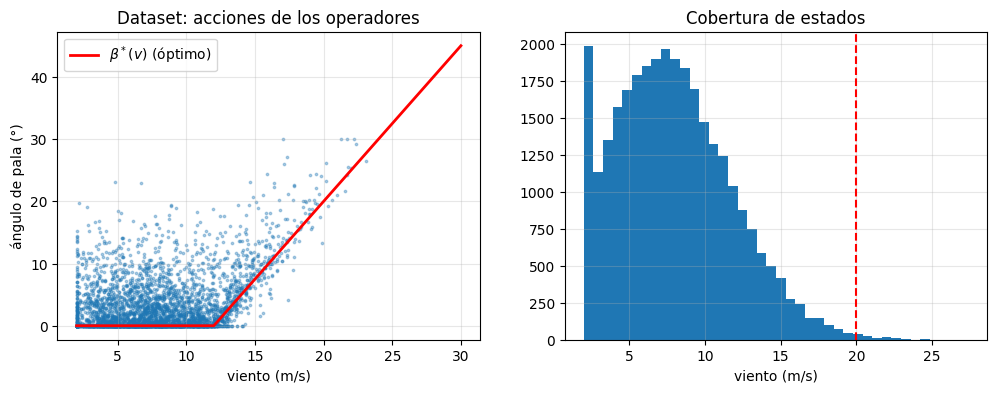

Muestras con viento > 20 m/s: 0.35%  (n=104)
   experto:  97.5% de sus acciones están a <2° del óptimo
intermedio:  55.1% de sus acciones están a <2° del óptimo
    novato:  35.6% de sus acciones están a <2° del óptimo

Global: 61.9% cerca del óptimo -> beta no es óptima, pero tampoco inútil (mezcla).
Los pares (s,a) de viento extremo son escasos y los operadores allí se limitan a un rango estrecho => C1 (cobertura) es el cuello de botella.


In [6]:
# --- Demostración 5: cobertura de un dataset sintético generado por operadores de distinta experiencia ---
# SUPUESTO: cada operador actúa como beta*(v) + sesgo + ruido. El experto es casi determinista; el novato es ruidoso y conservador.
ops = {"experto":    dict(bias=0.0, sigma=1.0, w=0.3),
       "intermedio": dict(bias=1.5, sigma=3.0, w=0.4),
       "novato":     dict(bias=4.0, sigma=6.0, w=0.3)}
N = 30_000
# viento tipo Weibull (muchos días moderados, pocas ráfagas fuertes)
v = np.clip(rng.weibull(2.2, N) * 9.0, 2, 30)
who = rng.choice(list(ops), size=N, p=[o["w"] for o in ops.values()])
beta = np.array([np.clip(beta_star(vi) + ops[w]["bias"] + ops[w]["sigma"] * rng.standard_normal(), BETA_MIN, BETA_MAX)
                 for vi, w in zip(v, who)])

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
sel = rng.choice(N, 4000, replace=False)
axs[0].scatter(v[sel], beta[sel], s=3, alpha=.35)
vv = np.linspace(2, 30, 200)
axs[0].plot(vv, beta_star(vv), "r", lw=2, label=r"$\beta^*(v)$ (óptimo)"); axs[0].set_xlabel("viento (m/s)"); axs[0].set_ylabel("ángulo de pala (°)")
axs[0].legend(); axs[0].set_title("Dataset: acciones de los operadores")
h = axs[1].hist(v, bins=40); axs[1].axvline(20, color="r", ls="--"); axs[1].set_xlabel("viento (m/s)"); axs[1].set_title("Cobertura de estados")
plt.show()

print(f"Muestras con viento > 20 m/s: {(v>20).mean()*100:.2f}%  (n={(v>20).sum()})")
for k in ops:
    m = who == k
    near = (np.abs(beta[m] - beta_star(v[m])) < 2.0).mean() * 100
    print(f"{k:>10}: {near:5.1f}% de sus acciones están a <2° del óptimo")
print(f"\nGlobal: {(np.abs(beta - beta_star(v))<2).mean()*100:.1f}% cerca del óptimo -> beta no es óptima, pero tampoco inútil (mezcla).")
print("Los pares (s,a) de viento extremo son escasos y los operadores allí se limitan a un rango estrecho => C1 (cobertura) es el cuello de botella.")

---
# 1.1 (d)

## El problema: error de extrapolación

En Q-Learning/actor-crítico off-policy, el objetivo de Bellman evalúa el crítico en la acción que elegiría la **política actual**:
$$y = r + \gamma\, Q_{\theta^-}\big(s',\,a'\big),\qquad a' = \arg\max_a Q(s',a)\ \ \text{(o } \mu_\phi(s')\text{)}$$

Cuando se entrena **solo con un dataset fijo**, el crítico ha sido ajustado únicamente en pares $(s,a)\sim\mathcal{D}$. Para $a'$ **fuera del soporte** de $\mathcal{D}$, $Q_\theta(s',a')$ es una **extrapolación arbitraria** del aproximador de funciones, sin ningún dato que la corrija. Esto se agrava por tres mecanismos que se refuerzan:

1. **El $\max$ es un seleccionador de errores positivos:** entre todas las acciones, elige precisamente aquella donde la red *sobrestima* el valor (maldición del ganador). Es el mismo sesgo de sobrestimación de DQN, pero aquí sin válvula de escape.
2. **El *bootstrapping* propaga y amplifica el error:** el valor inflado de $(s',a')$ entra en el objetivo de $(s,a)$ y se propaga hacia atrás en el tiempo, acumulándose a lo largo del horizonte ($\sim 1/(1-\gamma)$).
3. **No hay retroalimentación del entorno:** en online RL, ejecutar la acción "ilusoria" revelaría que su valor real es bajo y el crítico se corregiría. En offline RL **nunca se ejecuta**, así que el error **nunca se corrige** (Fujimoto et al., 2019; Levine et al., 2020).

Resultado típico: $Q$ diverge o se vuelve optimista, y la política converge hacia acciones fuera de distribución donde el crítico está equivocado.


In [ ]:
# --- Demostración 6: error de extrapolación (Q-learning estándar) vs. CQL con log-sum-exp ---
from scipy.optimize import minimize
V = 18.0                                       # beta*(18) = 15 grados
def true_reward(b):
    base = reward(b, V)
    overspeed = 3.0 * np.maximum(0.0, (8.0 - b) / 8.0) ** 2     # castigo por ángulo bajo con viento fuerte
    return base - overspeed

DEG = 8
grid = np.linspace(BETA_MIN, BETA_MAX, 301)
def feats(b):                                   # crítico flexible: polinomios de Legendre en variable normalizada
    return np.polynomial.legendre.legvander((np.asarray(b) - 15.0) / 15.0, DEG)
Phi_grid = feats(grid)

def fit(b_data, y, alpha=0.0, lam=1e-4):
    # minimiza  MSE(Q(a_data), y) + alpha*( logsumexp_a Q(a) - E_data[Q(a)] ) + lam*|w|^2   (alpha=0 -> Q-learning estándar)
    P = feats(b_data); n = len(b_data); md = P.mean(0)
    def f(w):
        z = Phi_grid @ w; m = z.max(); sm = np.exp(z - m); lse = m + np.log(sm.mean()); sm /= sm.sum()
        L = np.mean((P @ w - y) ** 2) + alpha * (lse - md @ w) + lam * w @ w
        g = 2 / n * P.T @ (P @ w - y) + alpha * (Phi_grid.T @ sm - md) + 2 * lam * w
        return L, g
    return minimize(f, np.zeros(DEG + 1), jac=True, method="L-BFGS-B", options=dict(maxiter=2000)).x

def make_data(seed):
    r = np.random.default_rng(seed)
    b = np.clip(r.normal(11.0, 1.5, 80), 7, 15)                 # acciones de operadores (soporte ~[7,15])
    return b, true_reward(b) + 0.1 * r.standard_normal(len(b))

def run(seed, alpha):
    b, y = make_data(seed)
    w = fit(b, y, alpha); q = Phi_grid @ w; a_star = grid[np.argmax(q)]
    return a_star, q.max(), true_reward(a_star), (b.min(), b.max()), w

for name, alpha in [("Q-learning estándar", 0.0), ("CQL (alpha=1.0)", 1.0)]:
    out = [run(s, alpha) for s in range(150)]
    qh = np.array([o[1] for o in out]); rt = np.array([o[2] for o in out])
    ood = np.array([(o[0] < o[3][0] - 1) or (o[0] > o[3][1] + 1) for o in out])
    print(f"{name:>22}: acción fuera de soporte en {ood.mean()*100:5.1f}% de 150 semillas | "
          f"recompensa REAL media = {rt.mean():5.2f} | peor caso = {rt.min():6.2f}")
print(f"\nReferencia: óptimo real ~ {true_reward(grid).max():.2f}. Las acciones fuera de soporte pueden caer en la zona de sobrevelocidad (recompensa negativa).")

   Q-learning estándar: acción fuera de soporte en  48.7% de 150 semillas | recompensa REAL media =  0.65 | peor caso =  -2.97
       CQL (alpha=1.0): acción fuera de soporte en   0.0% de 150 semillas | recompensa REAL media =  0.83 | peor caso =   0.76

Referencia: óptimo real ~ 1.00. Las acciones fuera de soporte pueden caer en la zona de sobrevelocidad (recompensa negativa).


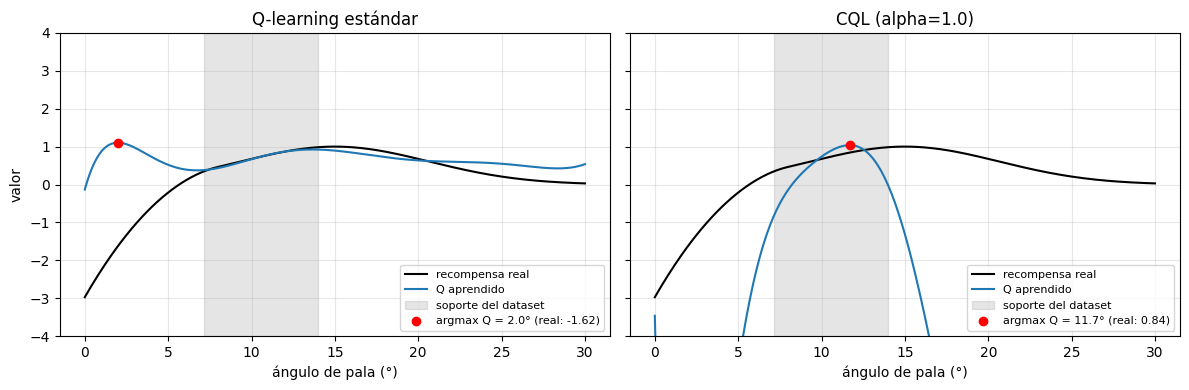

In [8]:
# Visualización de un caso donde el Q-learning estándar extrapola mal
seed = next(s for s in range(150) if true_reward(run(s, 0.0)[0]) < 0.3)
b, _ = make_data(seed)
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (name, alpha) in zip(axs, [("Q-learning estándar", 0.0), ("CQL (alpha=1.0)", 1.0)]):
    a_star, qmax, rt, _, w = run(seed, alpha)
    ax.plot(grid, true_reward(grid), "k", label="recompensa real")
    ax.plot(grid, Phi_grid @ w, "C0", label="Q aprendido")
    ax.axvspan(b.min(), b.max(), color="gray", alpha=.2, label="soporte del dataset")
    ax.scatter([a_star], [qmax], c="r", zorder=5, label=f"argmax Q = {a_star:.1f}° (real: {rt:.2f})")
    ax.set_ylim(-4, 4); ax.set_xlabel("ángulo de pala (°)"); ax.set_title(name); ax.legend(loc="lower right", fontsize=8)
axs[0].set_ylabel("valor")
plt.tight_layout(); plt.show()

el crítico extrapola fuera del soporte (zona gris), el $\arg\max$ **cae en los extremos** donde $Q$ está inflado y la acción elegida es mala *en la realidad* (la recompensa real incluye la penalización por sobrevelocidad que el dataset nunca mostró). Con la penalización conservadora (CQL), $Q$ queda "anclado" a los datos: el $\arg\max$ permanece dentro o cerca del soporte y la recompensa real es mucho mejor. Este es el mecanismo exacto por el cual CQL (y BCQ, IQL, TD3+BC, etc.) hace viable el offline RL.

## Referencias
- Silver et al. (2014). *Deterministic Policy Gradient Algorithms.* ICML.
- Lillicrap et al. (2015). *Continuous control with deep reinforcement learning (DDPG).*
- Fujimoto, van Hoof, Meger (2018). *Addressing Function Approximation Error in Actor-Critic Methods (TD3).* ICML.
- Haarnoja et al. (2018). *Soft Actor-Critic: Off-Policy Maximum Entropy Deep RL with a Stochastic Actor.* ICML.
- Fujimoto, Meger, Precup (2019). *Off-Policy Deep RL without Exploration (BCQ).* ICML.
- Kumar, Zhou, Tucker, Levine (2020). *Conservative Q-Learning for Offline RL.* NeurIPS.
- Levine, Kumar, Tucker, Fu (2020). *Offline RL: Tutorial, Review, and Perspectives on Open Problems.*